# Analysis and Visualization of Model Notebook

This notebook analyzes the Logistic Regression model selected as the best classifier for detecting malignant breast tumors. Instead of evaluating model accuracy, this notebook focuses on interpreting the best model behavior, identifying influential tumor features, and visualizing how tumor characteristics relate to cancer risk. The goal is to answer the research questions and demonstrate how the model can assist early cancer detection.

I will answer each research questions regarding the breast tumors with the best model constructed.

### 1. Which machine learning algorithms provide the highest accuracy?
This question is answered using the evaluation results from the Model Construction notebook. Among all models tested—Logistic Regression, KNN, Decision Tree, and the Voting Ensemble, Logistic Regression achieved the highest overall performance. While the Voting Ensemble and KNN produced an accuracy that was very close to Logistic Regression, the Logistic Regression model demonstrated better recall and F1 score, which are especially important in medical diagnosis since they reflect how well the model identifies malignant tumors.

The ROC comparison also showed that Logistic Regression separates the two classes more consistently and produces cleaner probability boundaries. Therefore, based on both accuracy and clinical relevance, Logistic Regression is the most reliable and effective model for this classification task.


### Logistics Regression Model Data Loading

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score


train_df = pd.read_csv("../data/train/train.csv")
val_df   = pd.read_csv("../data/val/val.csv")
test_df  = pd.read_csv("../data/test/test.csv")


X_train = train_df.drop(columns=["Diagnosis"]).to_numpy()
y_train = train_df["Diagnosis"].to_numpy()

X_val   = val_df.drop(columns=["Diagnosis"]).to_numpy()
y_val   = val_df["Diagnosis"].to_numpy()

X_test  = test_df.drop(columns=["Diagnosis"]).to_numpy()
y_test  = test_df["Diagnosis"].to_numpy()

feature_names = train_df.drop(columns=["Diagnosis"]).columns

Lg = LogisticRegression(max_iter=500, solver="liblinear", random_state=42)
Lg.fit(X_train, y_train)

print("Train accuracy:", Lg.score(X_train, y_train))
print("Test  accuracy:", Lg.score(X_test, y_test))


Train accuracy: 0.9874371859296482
Test  accuracy: 0.9767441860465116


### 2. What are the measurement of tumors that can cause breast cancers?

In [47]:
coef = Lg.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coef,
    "abs_coef": np.abs(coef)
}).sort_values("abs_coef", ascending=False)

coef_df.head(10)

,feature,coef,abs_coef
21,texture_3,1.373999,1.373999
10,radius_2,1.214320,1.214320
28,symmetry_3,1.077204,1.077204
13,area_2,0.941225,0.941225
15,compactness_2,-0.913868,0.913868
23,area_3,0.908859,0.908859
7,concave_points_1,0.859029,0.859029
20,radius_3,0.844973,0.844973
26,concavity_3,0.831026,0.831026
6,concavity_1,0.822359,0.822359


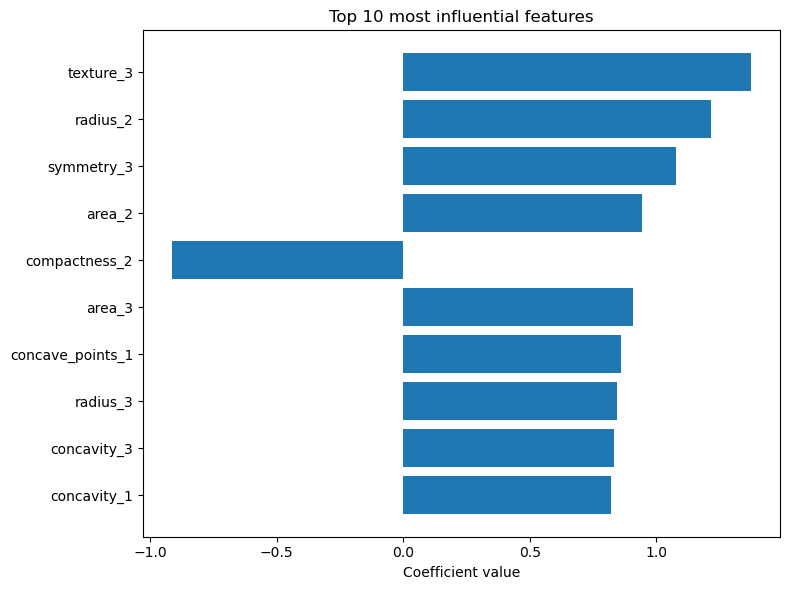

In [48]:
selected = 10
numofcof = coef_df.head(selected)
plt.figure(figsize=(8,6))
plt.barh(numofcof["feature"][::-1], top["coef"][::-1])
plt.xlabel("Coefficient value")
plt.title("Top 10 most influential features")
plt.tight_layout()
plt.show()

The plot above shows the features with the largest impact on the Logistic Regression predictions. These features fit into 3 important medical categories such as smoothness(texture_3, compactness_2), size(radius_2, radius_3, area_2, area_3) and shape(concave_points_1, concavity_1, concavity_3, symmetry_3), indicating that they are the most important measurements of detecting malignant.

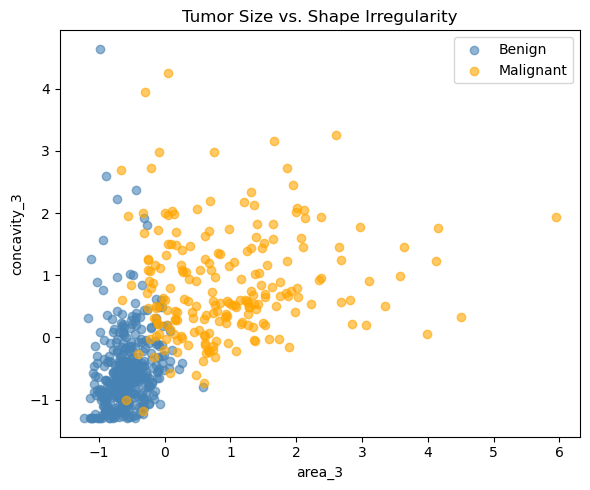

In [49]:
plt.figure(figsize=(6,5))

plt.scatter(
    all_df[all_df["Diagnosis"]==0]["area_3"],
    all_df[all_df["Diagnosis"]==0]["concavity_3"],
    alpha=0.6, label="Benign", color="steelblue"
)
plt.scatter(
    all_df[all_df["Diagnosis"]==1]["area_3"],
    all_df[all_df["Diagnosis"]==1]["concavity_3"],
    alpha=0.6, label="Malignant", color="orange"
)

plt.xlabel("area_3")
plt.ylabel("concavity_3")
plt.title("Tumor Size vs. Shape Irregularity")
plt.legend()
plt.tight_layout()
plt.show()


The scatter plot above combines two of the top features identified by Logistic Regression: area_3 and concavity_3. The plot shows a clear separation between benign and malignant tumors: benign samples cluster at small areas with low concavity and small area, while malignant samples appear at higher values for both. This demonstrates how tumor size and structural irregularity work together to classify breast cancer tumors.

### How the important features differ between two classifications: Benign and Malignant
To understand how the top features influence the classification, I plotted histograms for the top three Logistic Regression coefficients. In each histogram, the y-axis represents the number of samples, while the x-axis represents the standardized feature values divided into bins. These plots allow us to visualize how the feature values distribute for benign versus malignant tumors.

Across all three features, we observe a consistent pattern: benign tumors are concentrated toward the left (lower values), while malignant tumors tend to appear toward the right (higher values). This shift indicates that malignant tumors generally exhibit higher measurements in these important features. The separation between the two distributions shows why these features are powerful predictors in the Logistic Regression model and how increased values in these measurements are targeted to Malignant.

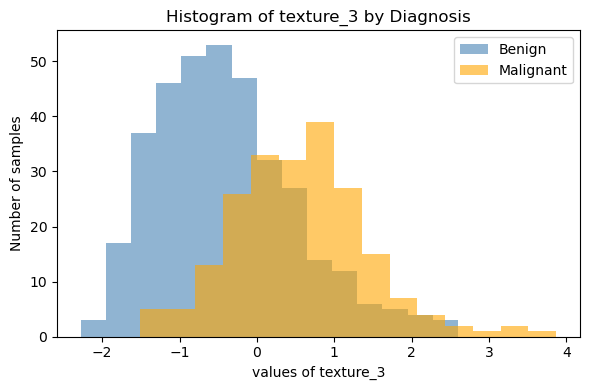

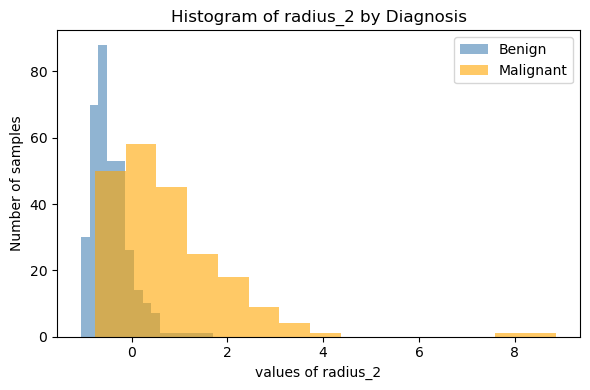

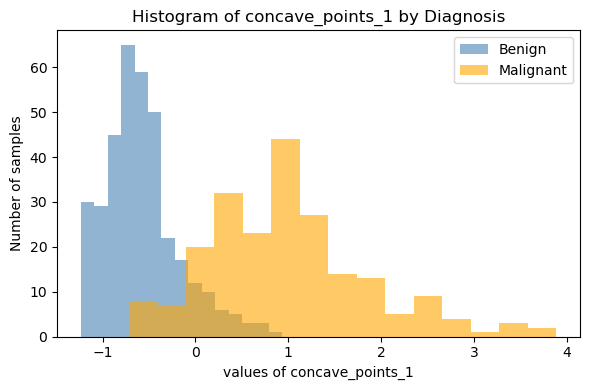

In [23]:
selected_features_q1 = ["texture_3", "radius_2", "concave_points_1"]

for feat in selected_features_q1:
    plt.figure(figsize=(6,4))
    
    plt.hist(
        all_df[all_df["Diagnosis"]==0][feat],
        bins=15, alpha=0.6, label="Benign", color="steelblue"
    )
    plt.hist(
        all_df[all_df["Diagnosis"]==1][feat],
        bins=15, alpha=0.6, label="Malignant", color="orange"
    )
    
    plt.title(f"Histogram of {feat} by Diagnosis")
    plt.xlabel(f"values of {feat}")
    plt.ylabel("Number of samples")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3. What other key factors should be considered such as smoothness, textures, and compactness?
From the histograms, we can see clear differences between benign and malignant tumors across the three important features. For texture_3, the malignant tumors appear more on the right side of the plot, meaning they generally have higher texture values. This shows that cancerous tissue has more variation and is less uniform.

For concave_points_1, the benign tumors stay mostly between –1 and 1, while malignant tumors spread into higher values. This means malignant tumors have more uneven, irregular edges, which is another sign of cancer.

Finally, for radius_2, malignant tumors tend to have larger values than benign ones, confirming that tumor size also helps separate the two classes.

Together, these plots show that higher texture, more irregular borders, and larger size are all important signs of malignancy.

### 4. How can we identify differences to help patients prevent cancer at early stages?
I will take all 30 features in Test dataset to compute the final probability of cancer as early detection should depend on how well the model separate between two class overall. 

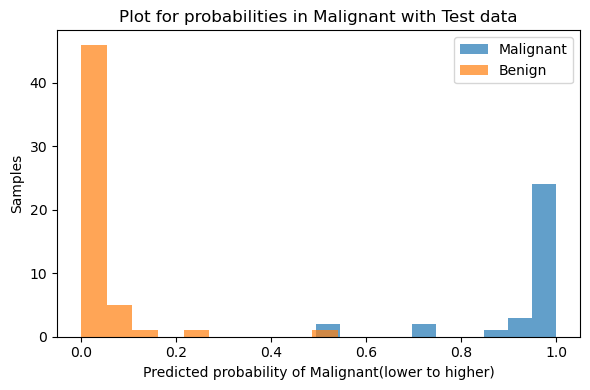

In [28]:
y_prob = Lg.predict_proba(X_test)[:, 1]

test_vis_df = pd.DataFrame(X_test, columns=feature_names)
test_vis_df["Diagnosis"] = y_test
test_vis_df["prob_malignant"] = y_prob

plt.figure(figsize=(6,4))
plt.hist(
    test_vis_df[test_vis_df["Diagnosis"] == 1]["prob_malignant"],
    bins=10, alpha=0.7, label="Malignant"
)
plt.hist(
    test_vis_df[test_vis_df["Diagnosis"] == 0]["prob_malignant"],
    bins=10, alpha=0.7, label="Benign"
)
plt.xlabel("Predicted probability of Malignant(lower to higher)")
plt.ylabel("Samples")
plt.title("Plot for probabilities in Malignant with Test data")
plt.legend()
plt.tight_layout()
plt.show()


The plot above shows that malignant cases cluster at high predicted probabilities, while benign cases remain near zero. This strong separation demonstrates that the model can identify high-risk tumors even in unseen data, supporting early identification and prevention.

### 5. How do tumor size, location, and stage affect spread?

This is my **model and data set Limitations**. The UCI Breast Cancer dataset used in this project does not contain information about tumor location or stage affect, so Logistic Regression cannot directly answer how these factors affect tumor spread. Logistic Regression is also a linear model, which means it tends to capture simple relationships between features and outcomes. More advanced models such as convolutional neural networks (CNNs) or multi-input neural networks could learn these relationships, but only if the dataset includes those kinds of informations. Without these inputs, models cannot infer location or stage.Therefore, my analysis focuses on size and shape features, which this dataset does provide.